# <center>Лабораторна робота №4. <br> Візуальний аналіз даних про пасажирів Титаніку</center>

**Заповніть код в клітинках замість "Ваш код тут"**

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Графіки відображаються в notebook автоматично.

**Зчитуємо навчальну вибірку.**

Доступ до даних на google drive, якщо ви відкриваєте блокнот в google colab, а не на PC, можна отримати шляхом монтування google drive

In [30]:
# Локальні дані знаходяться в lab4/data/.

In [31]:
from pathlib import Path
data_folder = Path("data")
if not (data_folder / "titanic_train.csv").exists():
    data_folder = Path("lab4/data")

In [32]:
train_df = pd.read_csv(data_folder / "titanic_train.csv", index_col="PassengerId")

In [33]:
train_df.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [34]:
train_df.describe(include='all')

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [35]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


**Відкинемо ознаку `Cabin`, а потім – всі рядки, де є пропуски.**

In [36]:
train_df = train_df.drop('Cabin', axis=1).dropna()

**Побудуйте попарні залежності ознак `Age`, `Fare`, `Pclass`, `Sex`, `SibSp`, `Parch`, `Embarked` и `Survived`. (метод `scatter_matrix ` Pandas чи `pairplot` Seaborn).**

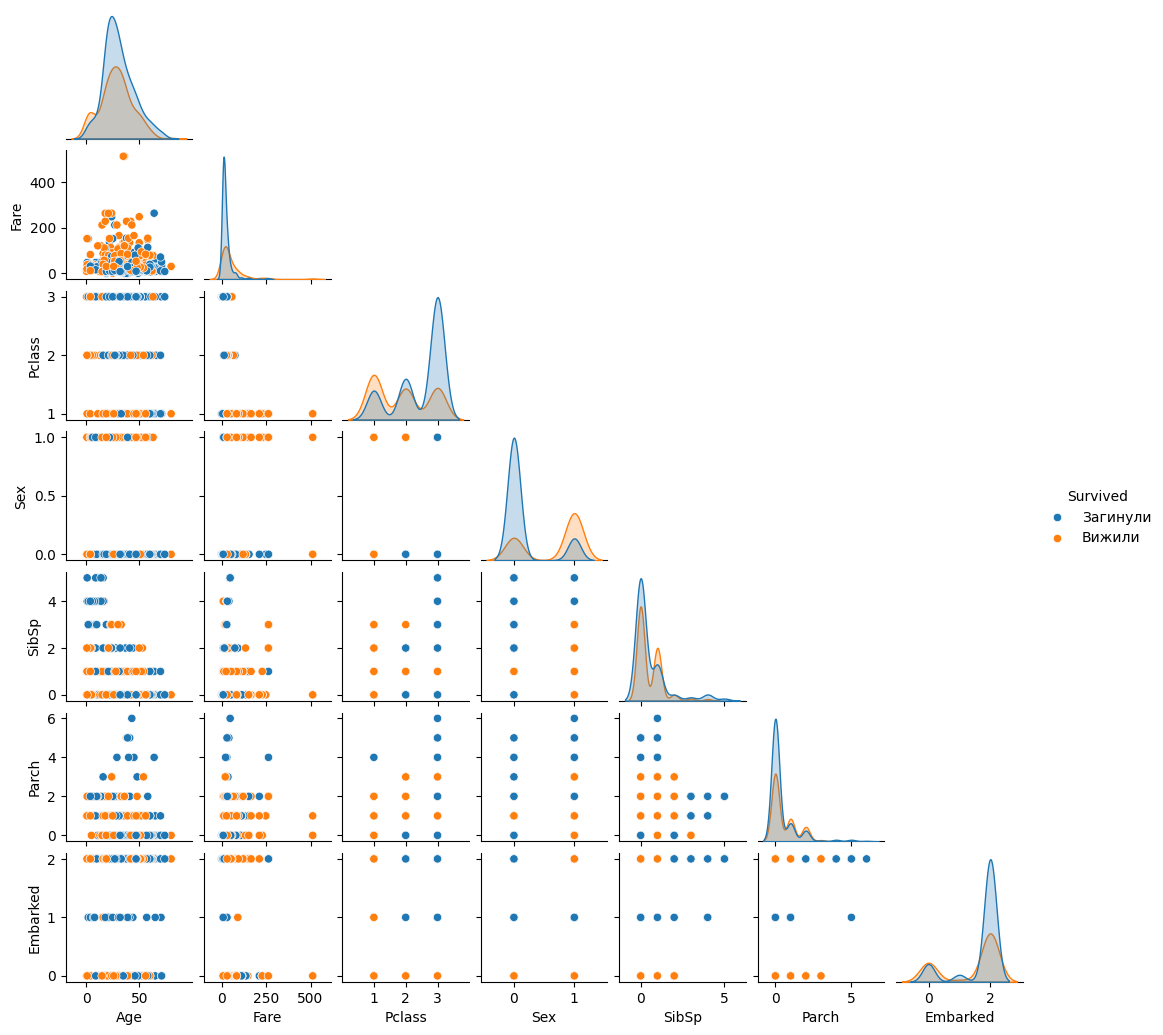

In [37]:
pair_data = train_df[['Age', 'Fare', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Survived']].copy()
pair_data['Sex'] = pair_data['Sex'].map({'male': 0, 'female': 1})
pair_data['Embarked'] = pair_data['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})
pair_data['Survived'] = pair_data['Survived'].map({0: 'Загинули', 1: 'Вижили'})
sns.pairplot(pair_data, hue='Survived', corner=True, height=1.5)
plt.show()

**Як плата за білет (`Fare`) залежить від класу каюти (`Pclass`)? Побудуйте boxplot.**

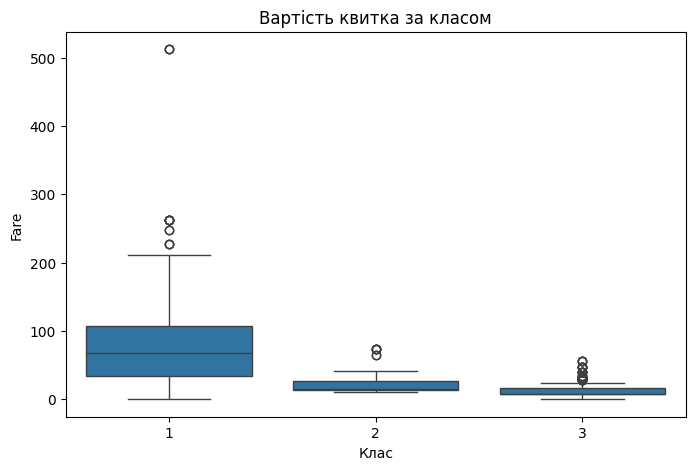

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x='Pclass', y='Fare')
plt.title('Вартість квитка за класом')
plt.xlabel('Клас')
plt.ylabel('Fare')
plt.show()

**Такий boxplot виходить не дуже красивим із-за викидів.** 

**Опціонально: створіть ознаку `Fare_no_out` (вартість без викидів), в якій виключається вартість, що відрізняється від середнього по класу більш ніж на 2 стандартних відхилення. Важливо: потрібно виключити викиди саме в залежності від класу каюти. Інакше виключатися будуть тільки найбільші (1 клас) і малі (3 клас) вартості.**

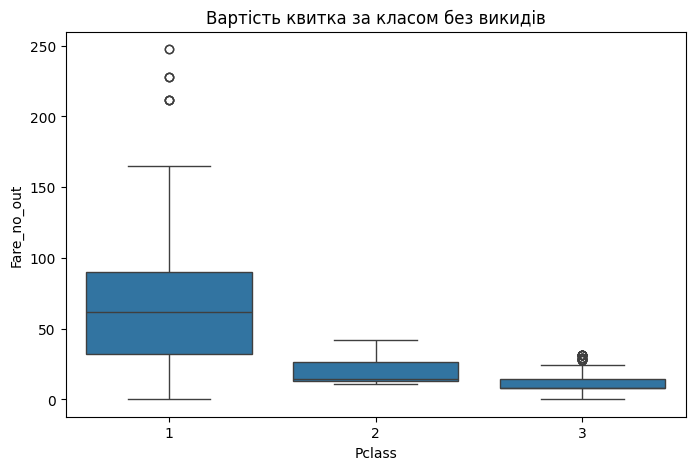

In [39]:
train_df['Fare_no_out'] = train_df['Fare']
fare_pclass1 = train_df[train_df['Pclass'] == 1]['Fare']
fare_pclass2 = train_df[train_df['Pclass'] == 2]['Fare']
fare_pclass3 = train_df[train_df['Pclass'] == 3]['Fare']
def without_outliers(series):
    return series[(series - series.mean()).abs() <= 2 * series.std()]
fare_pclass1_no_out = without_outliers(fare_pclass1)
fare_pclass2_no_out = without_outliers(fare_pclass2)
fare_pclass3_no_out = without_outliers(fare_pclass3)
train_df['Fare_no_out'] = pd.concat([fare_pclass1_no_out, fare_pclass2_no_out, fare_pclass3_no_out])
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x='Pclass', y='Fare_no_out')
plt.title('Вартість квитка за класом без викидів')
plt.show()

**Яке відношення загиблих і виживших в залежності від статі? Відобразіть з допомогою Seaborn.countplot з аргументом hue.**

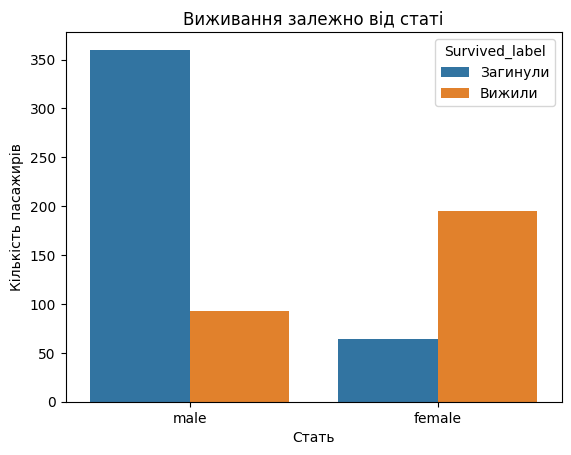

In [40]:
plot_data = train_df.assign(Survived_label=train_df['Survived'].map({0: 'Загинули', 1: 'Вижили'}))
sns.countplot(data=plot_data, x='Sex', hue='Survived_label')
plt.title('Виживання залежно від статі')
plt.xlabel('Стать')
plt.ylabel('Кількість пасажирів')
plt.show()

**Яке співідношення загиблих і виживших в залежності від класу каюти? Відобразівть за допомогою Seaborn.countplot з аргументом hue.**

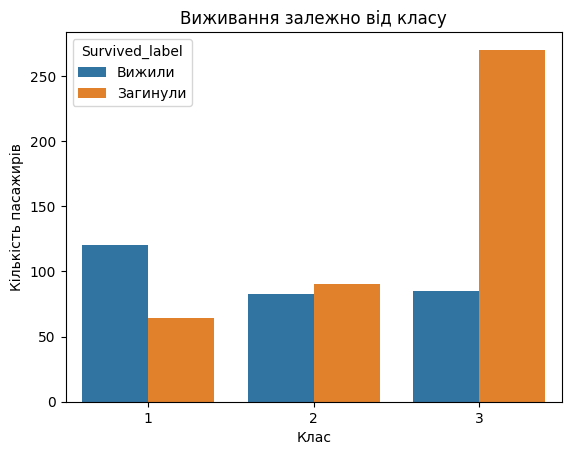

In [41]:
plot_data = train_df.assign(Survived_label=train_df['Survived'].map({0: 'Загинули', 1: 'Вижили'}))
sns.countplot(data=plot_data, x='Pclass', hue='Survived_label')
plt.title('Виживання залежно від класу')
plt.xlabel('Клас')
plt.ylabel('Кількість пасажирів')
plt.show()

**Як факт виживання залежить від віку пасажира? Перевірте (графічно) припущення, що молоді частіше виживали. Нехай, умовно, молоді - молодші 30 років, похилого віку – старші 60 років.**

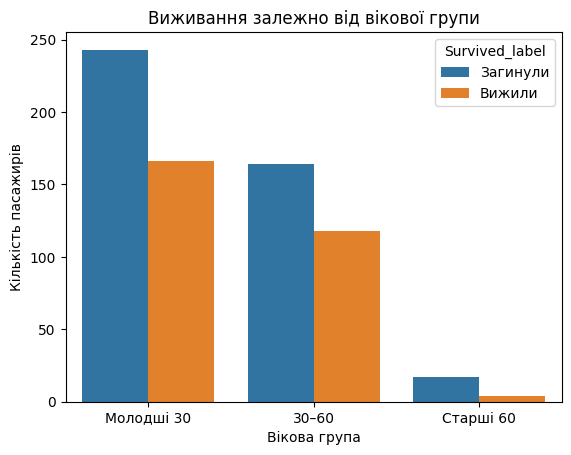

,"Частка виживших, %"
Age_group,
Молодші 30,40.59
30–60,41.84
Старші 60,19.05


In [42]:
train_df['Age_group'] = pd.cut(train_df['Age'], bins=[-1, 30, 60, float('inf')], labels=['Молодші 30', '30–60', 'Старші 60'])
plot_data = train_df.assign(Survived_label=train_df['Survived'].map({0: 'Загинули', 1: 'Вижили'}))
sns.countplot(data=plot_data, x='Age_group', hue='Survived_label')
plt.title('Виживання залежно від вікової групи')
plt.xlabel('Вікова група')
plt.ylabel('Кількість пасажирів')
plt.show()
survival_by_age_group = train_df.groupby('Age_group', observed=False)['Survived'].mean().mul(100).round(2)
survival_table = survival_by_age_group.to_frame('Частка виживших, %')
survival_table